# California — Adverse Events EDA
**Source:** CA Dept of Public Health, PRA #29194 (received 2026-04-08)
**Dataset:** Hospital-reported adverse events (2023-forward)
**Rows:** ~4,681 | **Facility types:** General Acute Care Hospital, Acute Psychiatric Hospital

This notebook explores reportable adverse events in California hospitals under HSC §1279.1.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})
sns.set_theme(style='whitegrid', palette='muted')


In [2]:
# ── Load data ──────────────────────────────────────────────────────────────
BASE = '../../data/source/California/'
detail   = pd.read_csv(BASE + 'CA - Final_PRA_29194 - 2026-04-08.xlsx - Detail.csv')
lookup   = pd.read_csv(BASE + 'CA - Final_PRA_29194 - 2026-04-08.xlsx - Lookup Table.csv')
data_dict = pd.read_csv(BASE + 'CA - Final_PRA_29194 - 2026-04-08.xlsx - Data Dictionary.csv')

# Parse date
detail['RECVDATE'] = pd.to_datetime(detail['RECVDATE'], dayfirst=False, errors='coerce')
detail['year']  = detail['RECVDATE'].dt.year
detail['month'] = detail['RECVDATE'].dt.to_period('M')

print(f"Rows: {len(detail):,}  |  Columns: {list(detail.columns)}")
detail.head(3)


Rows: 4,682  |  Columns: ['INTAKEID', 'RECVDATE', 'AE_CATEGORY', 'AE_SHORT', 'ADVERSE_EVENT', 'FINDING_DETAIL', 'ASPEN_FACID', 'NAME', 'ASPEN_FACTYPE_LABEL', 'year', 'month']


,INTAKEID,RECVDATE,AE_CATEGORY,AE_SHORT,ADVERSE_EVENT,FINDING_DETAIL,ASPEN_FACID,NAME,ASPEN_FACTYPE_LABEL,year,month
0,CA00819364,2023-01-04,04 - Care Management Events,17: Stage 3/4 Pressure Ulcer,"17: Stage 3 or 4 Pressure Ulcer, Acquired Afte...",Z2_Missing,CA220000019,ZUCKERBERG SAN FRANCISCO GENERAL HOSP & TRAUMA...,General Acute Care Hospital,2023,2023-01
1,CA00819439,2023-01-04,04 - Care Management Events,17: Stage 3/4 Pressure Ulcer,"17: Stage 3 or 4 Pressure Ulcer, Acquired Afte...",Z2_Missing,CA030000901,MERCY HOSPITAL OF FOLSOM,General Acute Care Hospital,2023,2023-01
2,CA00819831,2023-01-09,04 - Care Management Events,17: Stage 3/4 Pressure Ulcer,"17: Stage 3 or 4 Pressure Ulcer, Acquired Afte...",Z2_Missing,CA030000123,MEMORIAL MEDICAL CENTER,General Acute Care Hospital,2023,2023-01


In [3]:
# ── Overview ────────────────────────────────────────────────────────────────
print("=== Shape & dtypes ===")
print(detail.info())
print()
print("=== Missing values ===")
print(detail.isnull().sum())


=== Shape & dtypes ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4682 entries, 0 to 4681
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   INTAKEID             4682 non-null   object        
 1   RECVDATE             4682 non-null   datetime64[ns]
 2   AE_CATEGORY          4682 non-null   object        
 3   AE_SHORT             4682 non-null   object        
 4   ADVERSE_EVENT        4682 non-null   object        
 5   FINDING_DETAIL       4682 non-null   object        
 6   ASPEN_FACID          4682 non-null   object        
 7   NAME                 4682 non-null   object        
 8   ASPEN_FACTYPE_LABEL  4682 non-null   object        
 9   year                 4682 non-null   int32         
 10  month                4682 non-null   period[M]     
dtypes: datetime64[ns](1), int32(1), object(8), period[M](1)
memory usage: 384.2+ KB
None

=== Missing values ===
INTAKEID       

In [4]:
# ── Date range ──────────────────────────────────────────────────────────────
print(f"Date range: {detail['RECVDATE'].min().date()} → {detail['RECVDATE'].max().date()}")


Date range: 2023-01-03 → 2024-12-31


## 1 · Adverse Event Category Distribution

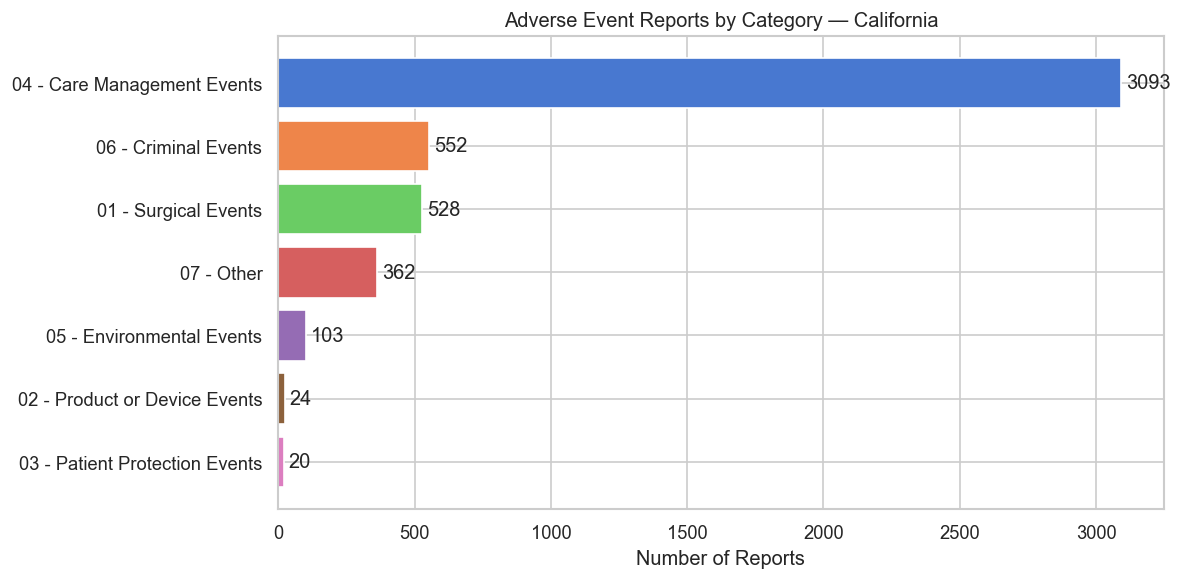

                                count   pct
AE_CATEGORY                                
04 - Care Management Events      3093  66.1
06 - Criminal Events              552  11.8
01 - Surgical Events              528  11.3
07 - Other                        362   7.7
05 - Environmental Events         103   2.2
02 - Product or Device Events      24   0.5
03 - Patient Protection Events     20   0.4


In [5]:
cat_counts = detail['AE_CATEGORY'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(cat_counts.index, cat_counts.values, color=sns.color_palette('muted', len(cat_counts)))
ax.bar_label(bars, padding=3)
ax.set_xlabel('Number of Reports')
ax.set_title('Adverse Event Reports by Category — California')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(cat_counts.to_frame('count').assign(pct=lambda d: (d['count']/d['count'].sum()*100).round(1)))


## 2 · Monthly Volume Trend

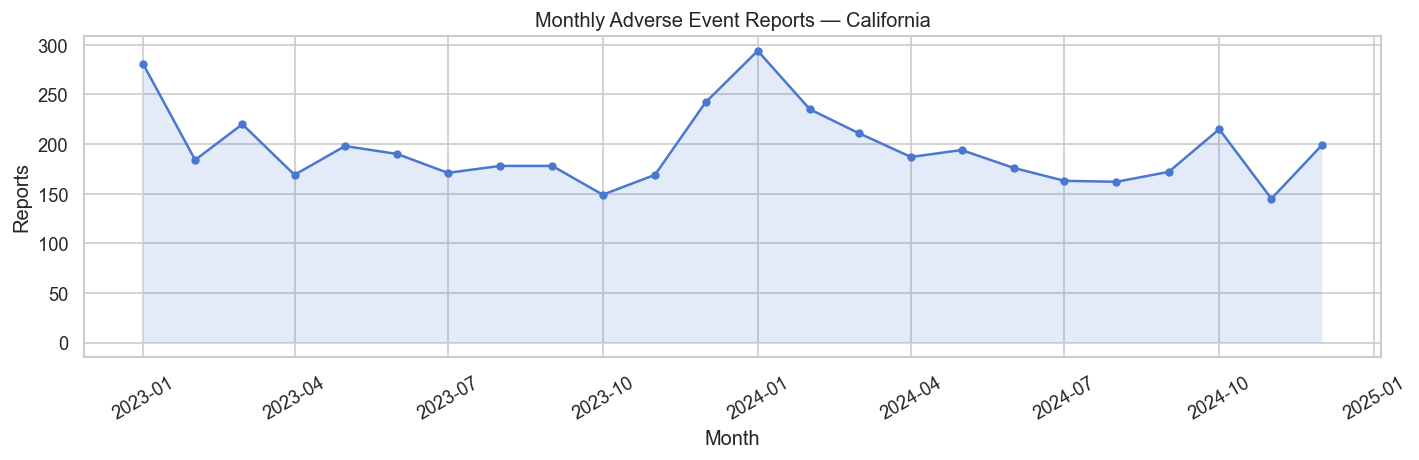

In [6]:
monthly = detail.groupby('month').size().reset_index(name='count')
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly['month_dt'], monthly['count'], marker='o', linewidth=1.5, markersize=4)
ax.fill_between(monthly['month_dt'], monthly['count'], alpha=0.15)
ax.set_title('Monthly Adverse Event Reports — California')
ax.set_xlabel('Month')
ax.set_ylabel('Reports')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 3 · Finding Detail (Investigation Outcome)

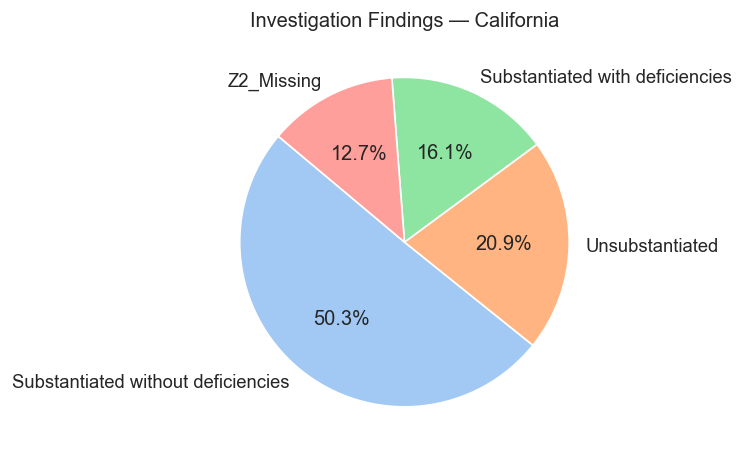

FINDING_DETAIL
Substantiated without deficiencies    2357
Unsubstantiated                        978
Substantiated with deficiencies        754
Z2_Missing                             593
Name: count, dtype: int64


In [7]:
finding = detail['FINDING_DETAIL'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
wedges, texts, autotexts = ax.pie(
    finding.values, labels=finding.index,
    autopct='%1.1f%%', startangle=140,
    colors=sns.color_palette('pastel', len(finding))
)
ax.set_title('Investigation Findings — California')
plt.tight_layout()
plt.show()

print(finding)


## 4 · Adverse Event Sub-type (AE_SHORT)

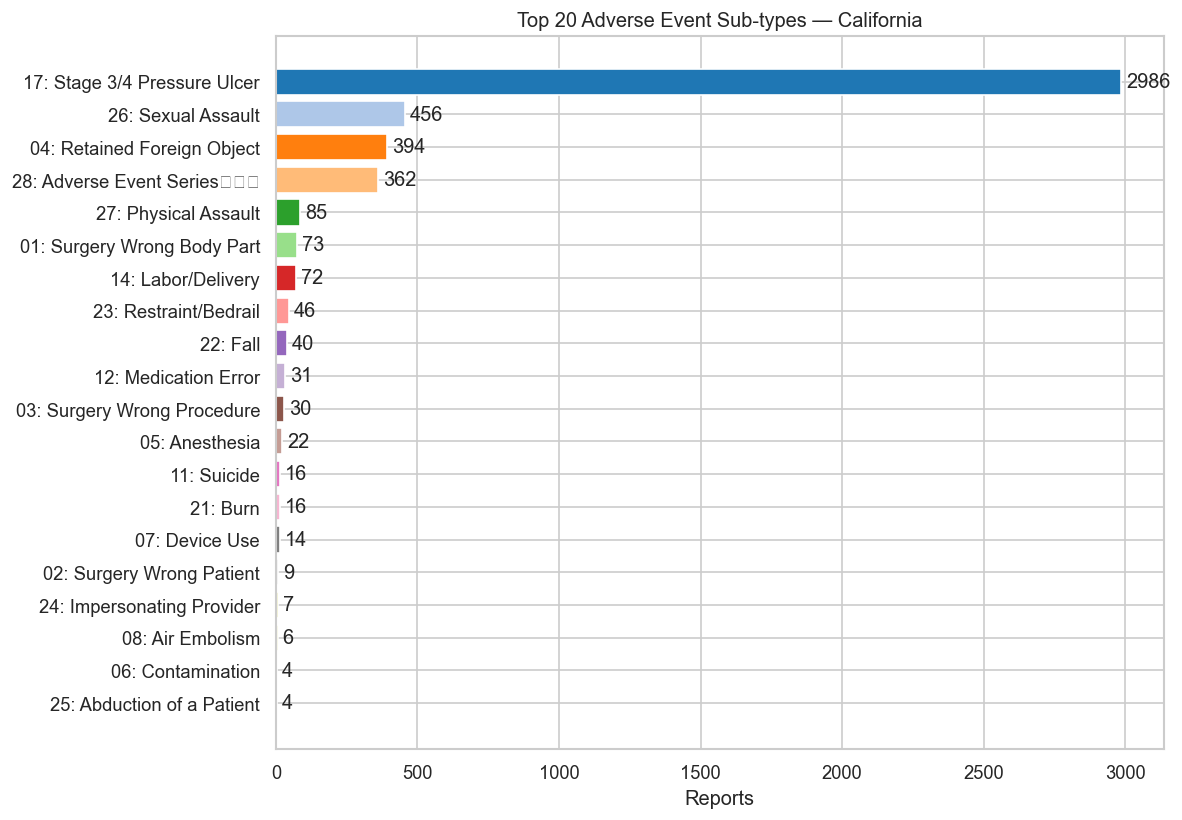

In [8]:
ae_short = detail['AE_SHORT'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(ae_short.index, ae_short.values, color=sns.color_palette('tab20', len(ae_short)))
ax.bar_label(bars, padding=3)
ax.set_xlabel('Reports')
ax.set_title('Top 20 Adverse Event Sub-types — California')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 5 · Top Facilities by Report Count

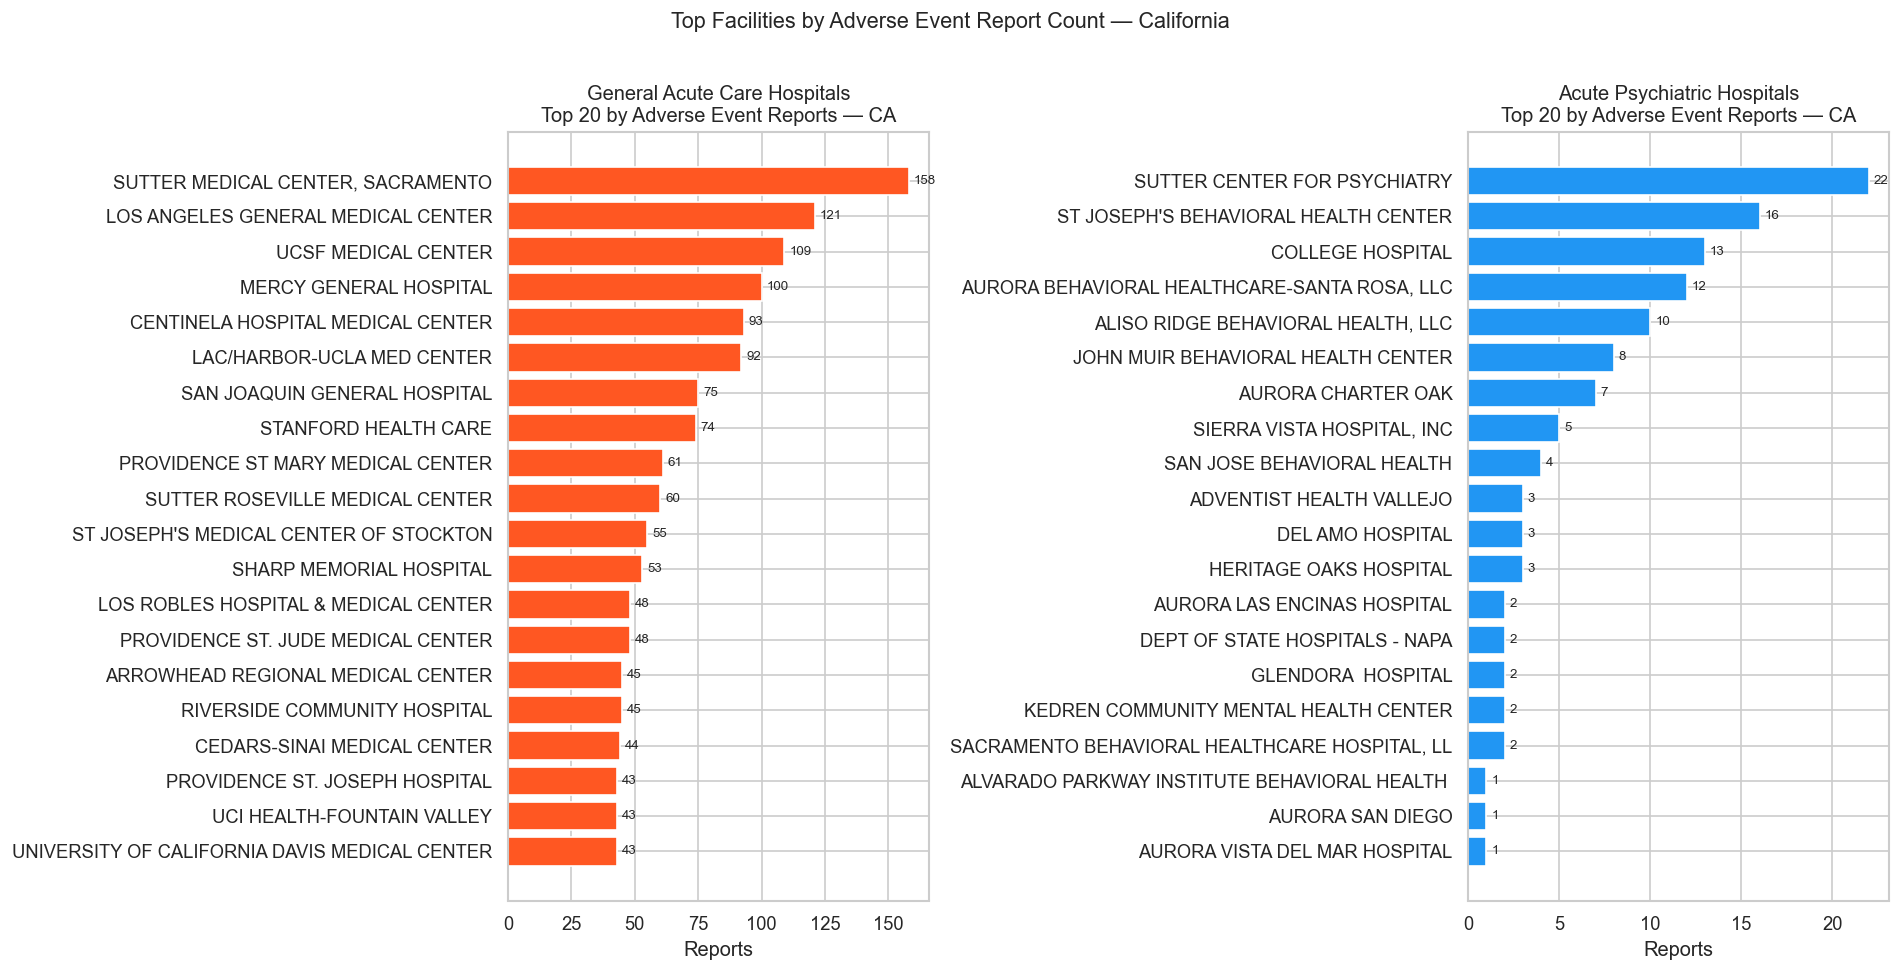

In [9]:
fac_counts = detail.groupby(['NAME', 'ASPEN_FACTYPE_LABEL']).size().reset_index(name='count')

gach = fac_counts[fac_counts['ASPEN_FACTYPE_LABEL'] == 'General Acute Care Hospital'].nlargest(20, 'count')
psych = fac_counts[fac_counts['ASPEN_FACTYPE_LABEL'] == 'Acute Psychiatric Hospital'].nlargest(20, 'count')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# General Acute Care
bars0 = axes[0].barh(gach['NAME'].str[:45], gach['count'], color='#FF5722')
axes[0].bar_label(bars0, padding=3, fontsize=8)
axes[0].set_xlabel('Reports')
axes[0].set_title('General Acute Care Hospitals\nTop 20 by Adverse Event Reports — CA')
axes[0].invert_yaxis()

# Acute Psychiatric
bars1 = axes[1].barh(psych['NAME'].str[:45], psych['count'], color='#2196F3')
axes[1].bar_label(bars1, padding=3, fontsize=8)
axes[1].set_xlabel('Reports')
axes[1].set_title('Acute Psychiatric Hospitals\nTop 20 by Adverse Event Reports — CA')
axes[1].invert_yaxis()

plt.suptitle('Top Facilities by Adverse Event Report Count — California', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 6 · Category × Finding Detail Heatmap

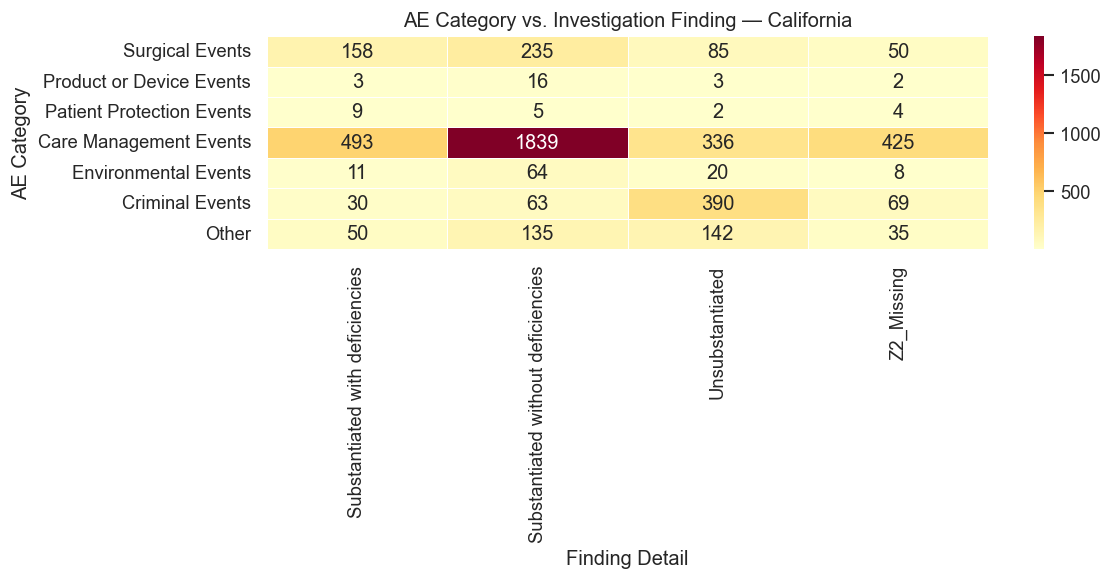

In [10]:
pivot = detail.groupby(['AE_CATEGORY', 'FINDING_DETAIL']).size().unstack(fill_value=0)
# Shorten category labels
pivot.index = pivot.index.str.replace(r'^\d{2} - ', '', regex=True)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('AE Category vs. Investigation Finding — California')
ax.set_xlabel('Finding Detail')
ax.set_ylabel('AE Category')
plt.tight_layout()
plt.show()


## 7 · Year-over-Year Comparison by Category

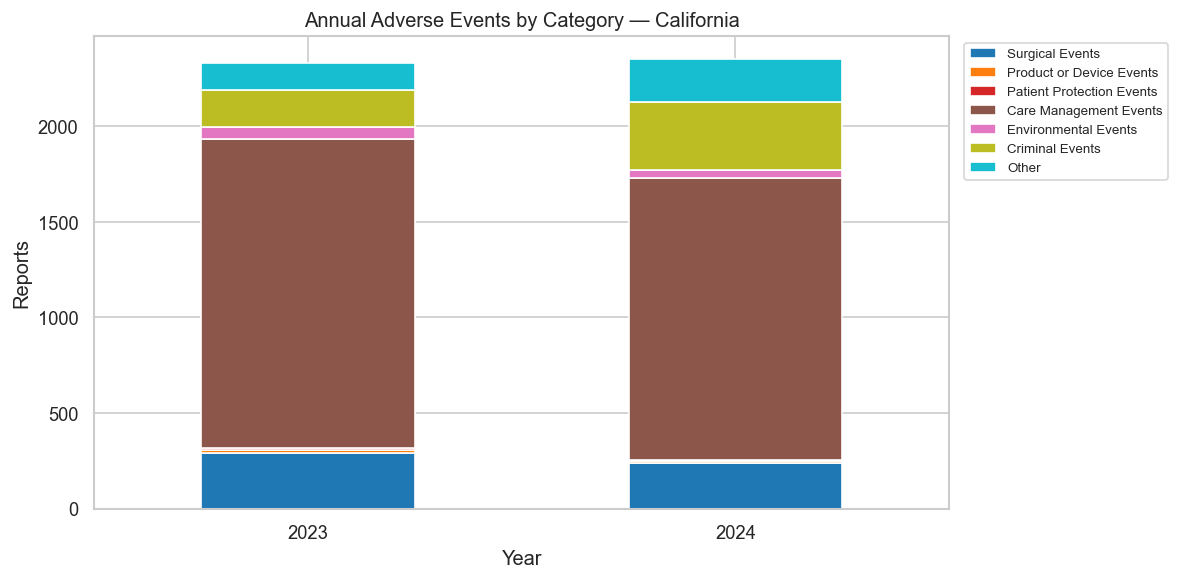

In [11]:
yoy = detail.groupby(['year', 'AE_CATEGORY']).size().unstack(fill_value=0)
yoy.columns = yoy.columns.str.replace(r'^\d{2} - ', '', regex=True)

ax = yoy.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='tab10')
ax.set_title('Annual Adverse Events by Category — California')
ax.set_xlabel('Year')
ax.set_ylabel('Reports')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 8 · Data Dictionary Reference

In [12]:
print("=== Data Dictionary ===")
print(data_dict.to_string(index=False))


=== Data Dictionary ===
          VARIABLES                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      DEFINITION
           INTAKEID                                                                                                                                                                                                                                                                                                                                                                                   INTAKEID lists the ASPEN system-generated ID for each complaint or facility reported i